


# Vamos encher o carrinho!

# Introdução

O Instacart é uma plataforma de entrega de supermercado onde os clientes podem fazer um pedido no supermercado e depois receber sua compra, semelhante ao funcionamento do Uber Eats e do iFood. O conjunto de dados que fornecemos foi modificado a partir do original. Reduzimos o tamanho dele para que seus cálculos sejam executados mais rapidamente e incluímos valores ausentes e duplicados. Também tivemos o cuidado de preservar as distribuições dos dados originais quando fizemos as alterações.

Você precisa completar três etapas. Para cada uma delas, escreva uma breve introdução descrevendo como você pretende concluir a etapa e justifique suas decisões em parágrafos explicativos a medida que você avança na solução. Escreva também uma conclusão para resumir suas conclusões e escolhas.



## Dicionário de dados

Há cinco tabelas no conjunto de dados, e você vai precisar usar todas elas para pré-processar seus dados e fazer AED. Abaixo está um dicionário que lista as colunas de cada tabela e descreve os dados contidos nelas.

- `instacart_orders.csv`: cada linha corresponde a um pedido no aplicativo da Instacart
    - `'order_id'`: é o número que identifica cada pedido de forma exclusiva
    - `'user_id'`: é o número de identificação exclusivo da conta de cada cliente
    - `'order_number'`: é o número de vezes que o cliente fez um pedido
    - `'order_dow'`: é o dia da semana em que o pedido foi feito (0 é domingo)
    - `'order_hour_of_day'`: é a hora do dia em que o pedido foi feito
    - `'days_since_prior_order'`: é o número de dias desde que o cliente fez seu pedido anterior




- `products.csv`: cada linha corresponde a um produto exclusivo que os clientes podem comprar
    - `'product_id'`: é o número de identificação unívoco de cada produto
    - `'product_name'`: é o nome do produto
    - `'aisle_id'`: é o número de identificação exclusivo de cada categoria de corredor do supermercado
    - `'department_id'`: é o número de identificação exclusivo de cada categoria de departamento do supermercado




-	`order_products.csv`: cada linha corresponde a um item incluído em um pedido
    -	`'order_id'`: é o número que identifica cada pedido de forma exclusiva
    -	`'product_id'`: é o número de identificação exclusivo de cada produto
    -	`'add_to_cart_order'`: é a ordem sequencial em que cada item foi colocado no carrinho
    -	`'reordered'`: 0 se o cliente nunca comprou o produto antes, 1 se já o comprou




-	`aisles.csv`
    -	`'aisle_id'`: é o número de identificação exclusivo de cada categoria de corredor do supermercado
    -	`'aisle'`: é o nome do corredor



-	`departments.csv`
    -	`'department_id'`: é o número de identificação exclusivo de cada categoria de departamento do supermercado
    -	`'department'`: é o nome do departamento


# Etapa 1. Visão geral dos dados

Leia os arquivos de dados (/datasets/instacart_orders.csv, /datasets/products.csv, /datasets/aisles.csv, /datasets/departments.csv e /datasets/order_products.csv) com `pd.read_csv()` usando os parâmetros apropriados para fazer isso corretamente. Verifique as informações para cada DataFrame criado.


## Plano de solução

Escreva aqui seu plano para a Etapa 2. Visão geral dos dados

In [1]:
# Importa as bibliotecas
import pandas as pd
from matplotlib import pyplot as plt

In [2]:
# Lê os conjuntos de dados em DataFrames
instacart_orders = pd.read_csv('instacart_orders.csv', delimiter=';')
products = pd.read_csv('products.csv', delimiter=';')
aisles = pd.read_csv('aisles.csv', delimiter=';')
departments = pd.read_csv('departments.csv', delimiter=';')
order_products = pd.read_csv('order_products.csv', delimiter=';')

In [3]:
# Imprime as informações sobre cada DataFrame
instacart_orders.info()
print()
products.info()
print()
aisles.info()
print()
departments.info()
print()
order_products.info()

<class 'pandas.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB

<class 'pandas.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   product_id     49694 non-null  int64
 1   product_name   48436 non-null  str  
 2   aisle_id       49694 non-null  int64
 3   department_id  49694 non-null  int64
dtypes: int64(3), str(1)
memory usage: 1.5 MB

<class 'pandas.DataFr

## Conclusões

Escreva aqui suas conclusões intermediárias da Etapa 1. Visão geral dos dados

Os dataframes disponiveis apresentam quantidade massivas de dados, que proporciona volume suficiente para verificação das analises e hipéteses propostas

# Etapa 2. Preparação de dados

Faça o pré-processamento dos dados da seguinte maneira:

-	Verifique e corrija os tipos de dados (por exemplo, certifique-se de que as colunas de ID sejam números inteiros)
-	Identifique e preencha valores ausentes
-	Identifique e remova valores duplicados

Certifique-se de explicar que tipos de valores ausentes e duplicados você encontrou, como você os preencheu ou removeu, por que escolheu esses métodos e por que você acha que esses valores ausentes e duplicados estavam presentes no conjunto de dados.

## Plano de solução

Escreva aqui seu plano para a Etapa 2. Preparação de dados\
\
Primeiramente analisar os valores duplicados e se a remoção deles nao afetará o resultado final e depois verificar os dados ausentes

## Encontre e remova valores duplicados (e descreva por que você está fazendo suas escolhas)

### DataFrame `instacart_orders`

In [4]:
# Verifica se há pedidos duplicados
print(instacart_orders.duplicated().sum())

15


### Há linhas duplicadas? Se sim, o que elas têm em comum?

Sim, são completamente identicas demonstrando uma tipo de falha no arquivo original, o que pode ser removido tranquilamente com drop_duplicates

## Com base nas suas conclusões,
15 linha duplicadas, todos completamente identicas
## verifique todos os pedidos feitos às 2h da manhã nas quartas-feiras

In [5]:
print(instacart_orders[instacart_orders.duplicated(keep=False)].sort_values(by='order_number')) # Verifica os pedidos diplicados como solicitado

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
200059   1782114   106752             1          3                  2   
266232   1782114   106752             1          3                  2   
345917   2232988    82565             1          3                  2   
324868   2232988    82565             1          3                  2   
242618   1021560    53767             3          3                  2   
311713   1021560    53767             3          3                  2   
321100    408114    68324             4          3                  2   
119251    408114    68324             4          3                  2   
142258   2845099    31189            11          3                  2   
284038   2845099    31189            11          3                  2   
30371    1918001   188546            14          3                  2   
230807   1918001   188546            14          3                  2   
215294   2160484   107525            16          3 

O que esse resultado quer dizer?

In [6]:
# Remove pedidos duplicados
instacart_orders = instacart_orders.drop_duplicates() # Duplicadas explicitas removidas

In [7]:
# Verifiqua as linhas duplicadas mais uma vez
print(instacart_orders.duplicated().sum())

0


In [8]:
# Verifique novamente apenas os IDs de pedidos duplicados
print(instacart_orders[instacart_orders['order_id'] == 2232988]) # Esse ID estava entre os duplicados, foi usado para teste

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
324868   2232988    82565             1          3                  2   

        days_since_prior_order  
324868                     NaN  


### Descreva brevemente suas conclusões e o que você fez com elas.
Duplicados explicitos removidos, foi selecionado um ID aleatório para verificação

### DataFrame `products`

In [9]:
# Verifique se há linhas completamente duplicadas
print(products.duplicated().sum())

0


In [10]:
# Verifique apenas IDs dos produtos duplicados
print(products[products.duplicated(subset=['product_id'], keep=False)])

Empty DataFrame
Columns: [product_id, product_name, aisle_id, department_id]
Index: []


In [11]:
# Checagem inicial de duplicados exatos
initial_duplicates = products['product_name'].duplicated().sum()
nulls_count = products['product_name'].isna().sum()

# Normalização para caixa baixa para expor duplicados implícitos
products['product_name'] = products['product_name'].str.lower()
implicit_duplicates_count = products['product_name'].duplicated().sum()

# Exibição organizada dos resultados
print(f"Duplicados explícitos iniciais:",initial_duplicates)
print(f"Duplicados pós-normalização (lower):",implicit_duplicates_count)
print(f"Duplicados implícitos identificados:",implicit_duplicates_count - initial_duplicates)
print(f"Valores nulos em product_name:", nulls_count)


Duplicados explícitos iniciais: 1257
Duplicados pós-normalização (lower): 1361
Duplicados implícitos identificados: 104
Valores nulos em product_name: 1258


In [ ]:
# Verifica os nomes de produtos duplicados que não estão faltando
not_null_products = products[~products['product_name'].isna()] # Gera uma tabela sem nulos
print(not_null_products[not_null_products.duplicated(subset=['product_name'], keep=False)].sort_values(by='product_name')) # Verifica se os duplicados são completamente iguais
products = products.drop_duplicates(subset=['product_name']) # Remove os duplicados e os nulos

       product_id                               product_name  aisle_id  \
23339       23340  18-in-1 hemp peppermint pure-castile soap        25   
31844       31845  18-in-1 hemp peppermint pure-castile soap        25   
19941       19942            aged balsamic vinegar of modena        19   
13152       13153            aged balsamic vinegar of modena        19   
24830       24831         albacore solid white tuna in water        95   
...           ...                                        ...       ...   
46873       46874                         vitamin d3 5000 iu        47   
21366       21367              wild sardines in spring water        95   
40093       40094              wild sardines in spring water        95   
1826         1827           yams cut sweet potatoes in syrup        81   
38260       38261           yams cut sweet potatoes in syrup        81   

       department_id  
23339             11  
31844             11  
19941             13  
13152             1

### Descreva brevemente suas conclusões e o que você fez com elas.
As analises constavam que haviam 104 valores duplicados implicitos na tabela, junto com os valores nulos, totalizando 1361 linhas que poderiam ser descartadas

### DataFrame `departments`

In [13]:
# Verifique se há linhas completamente duplicadas
print(departments.duplicated().sum())

0


In [14]:
# Verifique apenas IDs duplicados de departamentos
print(departments['department_id'].duplicated().sum())

0


### Descreva brevemente suas conclusões e o que você fez com elas.
Foi usado .duplicated().sum() na tabela inteira e na coluna filtrada, ambos retornaram 0

### DataFrame `aisles`

In [15]:
# Verifique se há linhas completamente duplicadas
print(aisles.duplicated().sum())

0


In [16]:
# Verifique apenas IDs duplicados de corredores
print(aisles['aisle_id'].duplicated().sum())

0


### Descreva brevemente suas conclusões e o que você fez com elas.
Foi usado .duplicated().sum() na tabela inteira e na coluna filtrada, ambos retornaram 0

### DataFrame `order_products`

In [17]:
# Verifique se há linhas completamente duplicadas
print(order_products.duplicated().sum())

0


In [ ]:
# Verifique mais uma vez se há outros casos complicados de duplicados
print(order_products['order_id'].duplicated().sum())

4094961


### Descreva brevemente suas conclusões e o que você fez com elas.
Pode se dizer que os valores duplicados não são um erro, pois um pedido pode conter mais de 1 produto, gerando assim, dois ID's iguais que representam transações diferentes

## Encontre e remova valores ausentes


Ao processarmos valores duplicados, observamos que também temos valores ausentes que precisamos investigar nas seguintes colunas:

*	A coluna `'product_name'` da tabela products.
*	A coluna `'days_since_prior_order'` da tabela orders.
*	A coluna `'add_to_cart_order'` da tabela order_products.


### DataFrame `products`

In [19]:
# Investigação de valores ausentes em product_name
missint_products = products[products['product_name'].isna()]
print(missint_products)

# Tratamento do valor ausente preenchendo com 'Unknown'
products['product_name'] = products['product_name'].fillna('Unknown')

# Validação: confirmação de que não restam nulos
print()
print(f"Valores nulos em product_name: {products['product_name'].isna().sum()}")

    product_id product_name  aisle_id  department_id
37          38          NaN       100             21

Valores nulos em product_name: 0


### Descreva brevemente suas conclusões e o que você fez com elas.
Os valores ausentes foram tratados e definidos como unknown

### DataFrame `orders`

In [20]:
# Encontra os valores ausentes
print(instacart_orders.isna().sum())

order_id                      0
user_id                       0
order_number                  0
order_dow                     0
order_hour_of_day             0
days_since_prior_order    28817
dtype: int64


In [21]:
# Há valores ausentes para os clientes que não estão fazendo o primeiro pedido?
print(instacart_orders[instacart_orders['order_number'] == 1])

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
28        133707   182261             1          3                 10   
96        787445    25685             1          6                 18   
100       294410   111449             1          0                 19   
103      2869915   123958             1          4                 16   
104      2521921    42286             1          3                 18   
...          ...      ...           ...        ...                ...   
478895   2589657   205028             1          0                 16   
478896   2222353   141211             1          2                 13   
478922   2272807   204154             1          1                 15   
478926   2499542    68810             1          4                 19   
478945   1387033    22496             1          5                 14   

        days_since_prior_order  
28                         NaN  
96                         NaN  
100                     

### Descreva brevemente suas conclusões e o que você fez com elas.
O segundo codigo exibe exatamente 28817 linhas, onde pode-se afirmar que todos de days_since_prior_order são nulos

### DataFrame `order_products`

In [22]:
# Encontre os valores ausentes
print(order_products.isna().sum())

order_id               0
product_id             0
add_to_cart_order    836
reordered              0
dtype: int64


In [23]:
# Quais são os valores mínimo e máximo dessa coluna?
print(f"Valor máximo:",order_products['add_to_cart_order'].min())
print(f"Valor mínimo:",order_products['add_to_cart_order'].max())

Valor máximo: 1.0
Valor mínimo: 64.0


### Descreva brevemente suas conclusões.
836 Ausentes detectados em add_to_cart_order

In [24]:
# Salve todos os IDs dos pedidos com pelo menos um valor ausente em 'add_to_cart_order'
orders_with_null = order_products[order_products['add_to_cart_order'].isna()]['order_id'].unique()

In [25]:
# Todos os pedidos com valores ausentes contêm mais de 64 produtos?
filtered_orders = order_products[order_products['order_id'].isin(orders_with_null)]
# Agrupe os pedidos com dados ausentes por ID de pedido
more_than_64 = filtered_orders.groupby(by='order_id')['product_id'].count().min()
# Conte o número de 'product_id' em cada pedido e verifique o valor mínimo da contagem

### Descreva brevemente suas conclusões.
Sim, o valor foi acima de 64, significando que todos os pedidos com mais de 64 estão nulos\
Isso representa uma falha no sistema, onde quando o total de produtos for acima de 64, da erro

In [26]:
# Substitua valores ausentes na coluna 'add_to_cart_order' por 999 e converta a coluna para o tipo integer
order_products['add_to_cart_order'] = order_products['add_to_cart_order'].fillna(999).astype(int) # Transforma os valores nulos em 999 e inteiro
print(order_products['add_to_cart_order'].isna().sum())
print()
order_products.info()

0

<class 'pandas.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Dtype
---  ------             -----
 0   order_id           int64
 1   product_id         int64
 2   add_to_cart_order  int64
 3   reordered          int64
dtypes: int64(4)
memory usage: 138.7 MB


### Descreva brevemente suas conclusões e o que você fez com elas.

Valores nulos se tornaram 999, assim a coluna podendo virar o type INTEIRO

## Conclusões

### Escreva aqui suas conclusões intermediárias da Etapa 2. Preparação de dados
Algumas tabelas com valores duplicados, a maioria foi tratado, outras nao foram necessarias pelo contexto do dado\
Valores ausentes tambem foram tradados, e organizados de uma forma melhor de visualização

# Etapa 3. Análise de dados

Quando os dados estiverem processados ​​e prontos, execute a seguinte análise:

1.	Verifique se os valores nas colunas `'order_hour_of_day'` e `'order_dow'` na tabela `orders` fazem sentido (ou seja, os valores da coluna  `'order_hour_of_day'` variam de 0 a 23 e os da `'order_dow'` variam de 0 a 6).
2.	Crie um gráfico que mostre quantas pessoas fazem pedidos a cada hora do dia.
3.	Crie um gráfico que mostre em que dia da semana as pessoas fazem compras.
4.	Crie um gráfico que mostre quanto tempo as pessoas esperam até fazer seu próximo pedido e comente sobre os valores mínimo e máximo.


### [A1] Verifique se os valores fazem sentido

In [27]:
print(instacart_orders.describe())

           order_id        user_id   order_number      order_dow  \
count  4.789520e+05  478952.000000  478952.000000  478952.000000   
mean   1.709953e+06  102966.654911      17.157563       2.775051   
std    9.869537e+05   59525.292863      17.704457       2.045901   
min    4.000000e+00       2.000000       1.000000       0.000000   
25%    8.564698e+05   51413.750000       5.000000       1.000000   
50%    1.709521e+06  102633.000000      11.000000       3.000000   
75%    2.563002e+06  154419.000000      23.000000       5.000000   
max    3.421079e+06  206209.000000     100.000000       6.000000   

       order_hour_of_day  days_since_prior_order  
count      478952.000000           450135.000000  
mean           13.447034               11.101814  
std             4.224567                9.190004  
min             0.000000                0.000000  
25%            10.000000                4.000000  
50%            13.000000                7.000000  
75%            16.000000      

### Escreva suas conclusões aqui
Os dados fazem sentido, verificaçao rapida com o uso do print(instacart_orders.describe())\
order_dow = 0 e 6, order_hour_of_day = 0 e 23\
Respectivos min e max


### [A2] Quantas pessoas fazem pedidos a cada hora do dia?

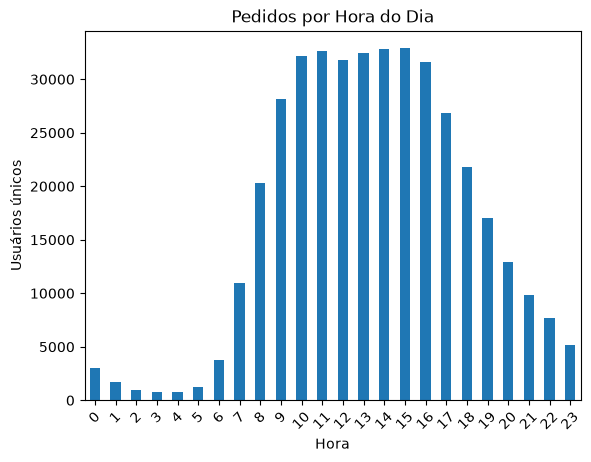

In [28]:
count_filter = instacart_orders.groupby('order_hour_of_day')['user_id'].nunique()
count_filter.plot(kind="bar",
                  title="Pedidos por Hora do Dia",
                  xlabel="Hora", 
                  ylabel="Usuários únicos",
                  rot=45)
plt.show()

### Escreva suas conclusões aqui
Nota-se que há um pico de pedidos entre 10h e 16h, mais de 30 mil por horario

### [A3] Em que dia da semana as pessoas compram produtos alimentícios?

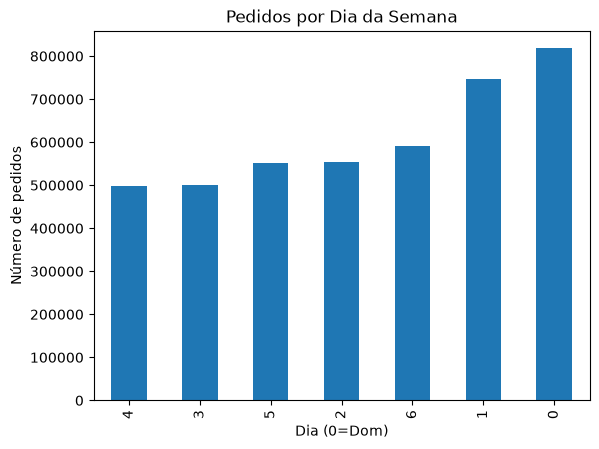

In [29]:
ids_food_related = [1, 3, 4, 6, 7, 9, 10, 12, 13, 14, 15, 16, 19, 20] # Departamentos alimenticios
food_products = products[products['department_id'].isin(ids_food_related)] # Produtos dos departamentos alimenticios
food_sales = order_products.merge(food_products, on='product_id', how='inner') # Filtra apenas as vendas de alimentos
final_analysis = food_sales.merge(instacart_orders, on='order_id', how='inner') # Filtra ao ID dos pedidos
food_orders_per_day = final_analysis.groupby('order_dow')['product_id'].count().sort_values() # Agrupa a venda dos alimentos por dia da semana
food_orders_per_day.plot(kind="bar", title="Pedidos por Dia da Semana",
                     xlabel="Dia (0=Dom)", ylabel="Número de pedidos")
plt.show()

### Escreva suas conclusões aqui
Nota-se que o dia onde há mais vendas de produtos alimenticios é no domingo

### [A4] Quanto tempo as pessoas esperam até fazer outro pedido?

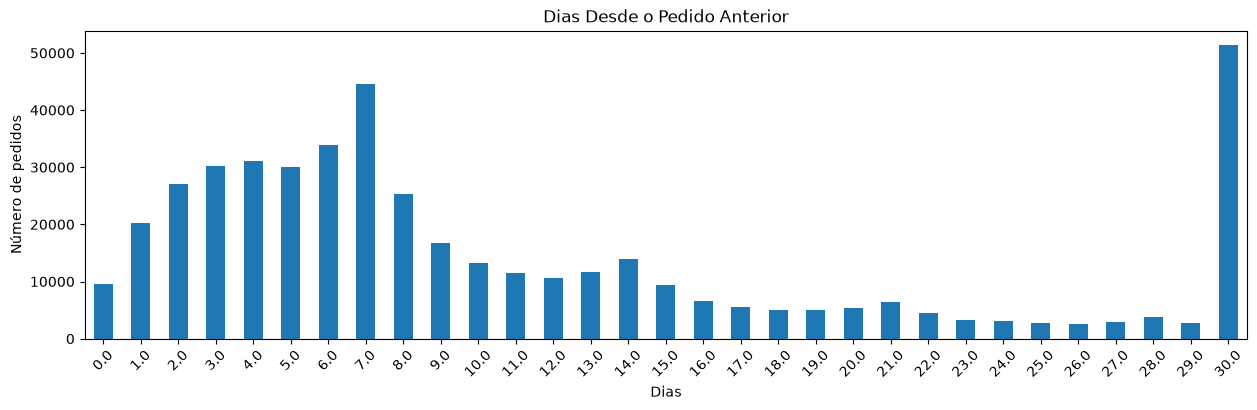

In [30]:
customer_waiting = instacart_orders['days_since_prior_order'].value_counts().sort_index()
customer_waiting.plot(kind="bar", title="Dias Desde o Pedido Anterior",
                      xlabel="Dias", ylabel="Número de pedidos", rot=45, figsize=(15,4))
plt.show()

### Escreva suas conclusões aqui
Nota-se aumentos de vendas a cada 7 dias, o que aponta que os clientes mantém compras semanais como rotina

1.	Há alguma diferença nas distribuições de `'order_hour_of_day'` nas quartas e sábados? Construa gráficos de barras para ambos os dias no mesmo gráfico e descreva as diferenças que você notou.
2.	Construa um gráfico de distribuição para o número de pedidos que os clientes fazem (ou seja, quantos clientes fizeram apenas 1 pedido, quantos fizeram apenas 2, quantos apenas 3, etc.)
3.	Quais são os 20 produtos comprados com mais frequência? Exiba os IDs e nomes.


### [B1] Diferenças nas quartas e sábados em `'order_hour_of_day'`. Crie gráficos de barras para ambos os dias e descreva as diferenças.

In [ ]:
df_wedday = instacart_orders[instacart_orders['order_dow'] == 3] # Separa as quartas-feiras
df_satday = instacart_orders[instacart_orders['order_dow'] == 6] # Separa os sábados

In [ ]:
wed_per_hour = df_wedday.groupby('order_hour_of_day')['order_id'].count() # Conta a quantidade de pedidas (quarta-feira)
sat_per_hour = df_satday.groupby('order_hour_of_day')['order_id'].count() # Conta a quantidade de pedidas (sábados)

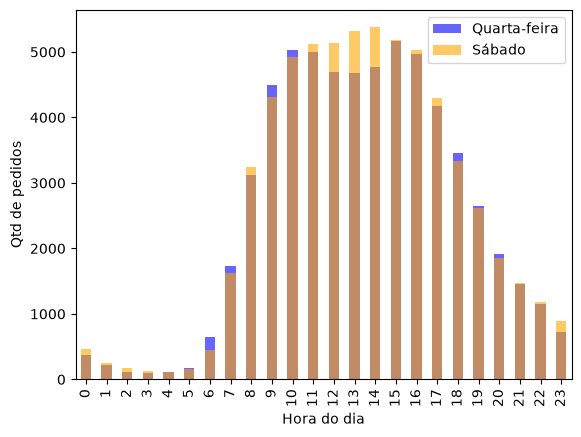

In [ ]:
wed_per_hour.plot(kind='bar', color='blue', alpha=0.6, label='Quarta-feira', xlabel='Hora do dia', ylabel='Qtd de pedidos') # Gera o grafico (quarta-feira)
sat_per_hour.plot(kind='bar', color='orange', alpha=0.6, label='Sábado', xlabel='Hora do dia') # Gera o grafico (sábados)
plt.legend()
plt.show()

### Escreva suas conclusões aqui
O grafico mostra que ambos os dias possuem uma quantidade alta de pedidos entre 10h e 16h, porém aos sábados a quantidade é maior que quarta-feira\
No caso, apenas as 10h da quarta-feira é o dia que mais possue vendas comparado ao sabado\
Detalhe que as vendas de quarta se mantém abaixo de 5 mil unidades, comparado a sabado que se mantem sempre acima

### [B2] Qual é a distribuição do número de pedidos por cliente?

In [ ]:
order_by_client = instacart_orders.groupby('user_id')['order_id'].count() # Separa o número de pedidos
order_distribution = order_by_client.value_counts().sort_index() # Conta o número de pedidos

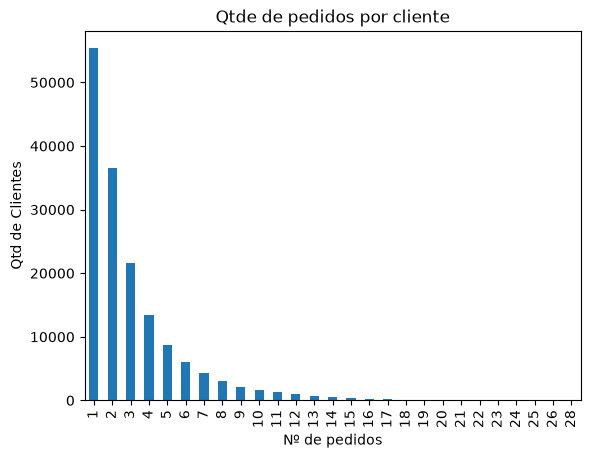

In [35]:
order_distribution.plot(kind='bar', title='Qtde de pedidos por cliente', xlabel='Nº de pedidos', ylabel='Qtd de Clientes') # Gera o grafico
plt.show()

### Escreva suas conclusões aqui
Nota-se no grafico que a maior parte dos clientes (mais de 50 mil) fizeram apenas 1 pedido, e uma breve quantidade, cerca de 120 clientes, fizeram 18 pedidos ou mais

### [B3] Quais são os 20 produtos mais populares? Exiba os IDs e nomes.

In [ ]:
products_by_order = order_products['product_id'].value_counts().head(20).reset_index() # Conta os primeiro 20 produtos (Os mais vendidos)
products_by_order.columns = ['product_id', 'quantidade_vendas'] # Renomeia colunas para melhor visualização
products_merged = products_by_order.merge(products, on='product_id') # Junta a tabela produtos com o top 20
print(products_merged)

    product_id  quantidade_vendas              product_name  aisle_id  \
0        24852              66050                    banana        24   
1        13176              53297    bag of organic bananas        24   
2        21137              37039      organic strawberries        24   
3        21903              33971      organic baby spinach       123   
4        47209              29773      organic hass avocado        24   
5        47766              24689           organic avocado        24   
6        47626              21495               large lemon        24   
7        16797              20018              strawberries        24   
8        26209              19690                     limes        24   
9        27845              19600        organic whole milk        84   
10       27966              19197       organic raspberries       123   
11       22935              15898      organic yellow onion        83   
12       24964              15292            organi

### Escreva suas conclusões aqui
Conclui-se que o departamento de hortifruit tem dominio sobre os produtos mais vendidos

1.	Quantos itens as pessoas normalmente compram em um pedido? Como fica a distribuição?
2.	Quais são os 20 principais itens incluídos mais frequentemente em pedidos repetidos? Exiba os IDs e nomes.
3.	Para cada produto, qual parcela de seus pedidos são repetidos? Crie uma tabela com colunas de ID e nome do produto e a proporção de pedidos repetidos.
4.	Para cada cliente, qual proporção de todos os seus pedidos são repetidos?
5.	Quais são os 20 principais itens que as pessoas colocam nos carrinhos antes de todos os outros? Exiba o ID do produto, nome e o número de vezes que ele foi o primeiro a ser adicionado a um carrinho.


### [C1] Quantos itens as pessoas normalmente compram em um pedido? Como fica a distribuição?

In [ ]:
products_per_order = (order_products.groupby('order_id')['product_id'].count()) # Conta dos produtos por pedido
ppo_mean = products_per_order.mean() # Calcula a média
ppo_median = products_per_order.median() # Calcula a mediana

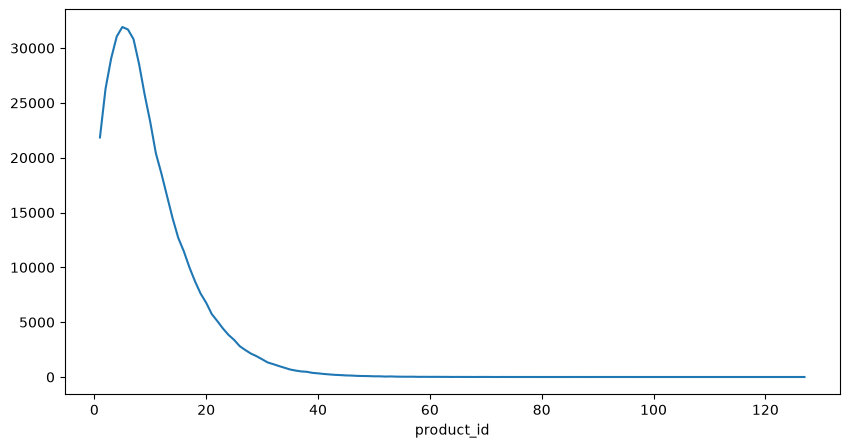

In [38]:
products_distribution = products_per_order.value_counts().sort_index() # Conta a quantidade de carrinhos com X produtos
products_distribution.plot(figsize=(10,5))
plt.show()

### Escreva suas conclusões aqui
Nota-se que a temos em media 10 produtos pro carrinho, e a maior parte dos clientes levaram 8 produtos

### [C2] Quais são os 20 principais itens incluídos com mais frequência em pedidos repetidos? Exiba os IDs e nomes.

In [39]:
reordered = order_products[order_products['reordered'] == 1] # Separa os pedidos repetidos

In [40]:
products_repeted = reordered['product_id'].value_counts().head(20).reset_index() # Conta os produtos repetidos

In [41]:
products_repeted.columns = ['product_id', 'repeted_times'] # Renomeia para melhor visualização

In [42]:
repeted_merged = products_repeted.merge(products, on='product_id') # Junta a tabela produtos para lozalizar o top 20

### Escreva suas conclusões aqui
Conclui-se que mais uma vez o setor hortifruti vem no topo da lista, seguido de produtos organicos

### [C3] Para cada produto, qual parcela de todos os pedidos dele são repetidos?

In [43]:
prop_reordered = order_products.groupby('product_id')['reordered'].mean().reset_index() # Procura a média dos pedidos repetidos
prop_reordered.columns = ['product_id', 'prop_reordered'] # Renomeia as colunas para melhor visualização

In [44]:
prop_reordered_merged = prop_reordered.merge(products, on='product_id') # Junta o df criando com o df products
prop_reordered_merged = prop_reordered_merged.drop(columns=['aisle_id', 'department_id']).sort_values(by='prop_reordered', ascending=False) # Remove as colunas desnecessarias e ordena pelos itens mais repetidos

### Escreva suas conclusões aqui
O resultado exibe produtos de nichos e departamentos diferentes\
Pode-se ter uma breve conclusão que são itens onde a taxa de venda e relativamente baixa, e por isso se destacam

### [C4] Para cada cliente, qual proporção de todos os seus pedidos são repetidos?

In [ ]:
merge_by_order = order_products.merge(instacart_orders, on='order_id') # Ordena por ID de pedido, unificando as informações necessárias
print(merge_by_order)
user_items = merge_by_order.groupby('user_id')['reordered'].mean().reset_index() # Calcula a média dos itens repetidos

         order_id  product_id  add_to_cart_order  reordered  user_id  \
0         2141543       11440                 17          0    58454   
1          567889        1560                  1          1   129474   
2         2261212       26683                  1          1    47476   
3          491251        8670                 35          1   134505   
4         2571142        1940                  5          1   155995   
...           ...         ...                ...        ...      ...   
4545002    577211       15290                 12          1    76414   
4545003   1219554       21914                  9          0   163902   
4545004    692640       47766                  4          1      597   
4545005    319435         691                  8          1     7124   
4545006   1398151       28733                  9          0    85144   

         order_number  order_dow  order_hour_of_day  days_since_prior_order  
0                  25          0                 15      

In [46]:
user_items.columns = ['user_id', 'user_reord_prop'] # Renomeia as colunas para melhor visualização
user_items = user_items.sort_values(by='user_reord_prop', ascending=False) # Ordena pela mario proporção
print(user_items['user_reord_prop'].mean()) # Obtém a média

0.4948531736151642


Em média, 50% dos produtos comprados são repetidos pelos clientes

# Conclusões:

- Podemos tirar conclusão que os pedidos os pedidos possuem um horario de pico no começo da tarde, junto a isso, muitos pedidos sao realizados nas segundas-feiras e nos domingos (indicando reestoque semanal)
- Cada cliente leva em media 10 itens, me arriscando a dizer que ele compram produtos e abastecimento rapido, e apenas uma minuscula parcela, realiza compras com grandes quantidade de produtos
- Os clientes tem preferencia em produtos hortifruti, onde monstra que alimentos frecos para consumo diarios é o foco deles, isso combina com a afirmação anterior, onde eles levam em media 10 produtos (consumo diario/rapido)

Com isso, podemos orientar o dono do comércio a priorizar a exibição e promoção dos produtos hortifruti e organico, que onde gera mais engajamento para os clientes